In [1]:
# ============================================================
# CELL 2: Imports
# ============================================================
import os
import json
import time
import random
import hashlib
from pathlib import Path
from typing import Dict

import numpy as np
import cv2
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
from torchvision import transforms as TVT

import matplotlib.pyplot as plt

import snntorch as snn
from snntorch import surrogate

In [ ]:


CONFIG = {
    # -----------------------------
    # Data
    # -----------------------------
    "base_dir": "data/ISIC2018",

    "train_dir": "ISIC2018_Task1-2_Training_Input",
    "train_mask_dir": "ISIC2018_Task1_Training_GroundTruth",

    "val_dir": "ISIC2018_Task1-2_Validation_Input",
    "val_mask_dir": "ISIC2018_Task1_Validation_GroundTruth",

    "test_dir": "ISIC2018_Task1-2_Test_Input",

    "img_size": [128, 128],
    "num_classes": 2,
    "batch_size": 8,
    "num_workers": 0,  # Windows safe

    # -----------------------------
    # Training
    # -----------------------------
    "epochs": 50,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "optimizer": "AdamW",

    # Scheduler
    "scheduler": "StepLR",
    "step_size": 15,
    "gamma": 0.5,

    # -----------------------------
    # Loss
    # -----------------------------
    "criterion": {
        "type": "ce"
    },

    # Other examples:
    # "criterion": {"type": "dice"},
    # "criterion": {"type": "tversky", "alpha": 0.5, "beta": 0.5},
    # "criterion": {
    #     "type": "combined",
    #     "weights": {"ce": 0.5, "dice": 0.3, "tversky": 0.2},
    #     "alpha": 0.5,
    #     "beta": 0.5
    # },

    # -----------------------------
    # SNN
    # -----------------------------
    "model": "SpikingULite",
    "T": 10,
    "beta": 1.0,
    "threshold": 1.0,
    "reset_mechanism": "zero",  # "zero" or "subtract"
    "surrogate": "ATan",
    "lif_state": "manual",

    # -----------------------------
    # Logging + resume
    # -----------------------------
    "out_dir": "./runs_spiking_ulite_isic",
    "resume": False,
    "seed": 42,
}


def make_run_name(cfg: dict) -> str:
    cfg_str = json.dumps(cfg, sort_keys=True)
    h = hashlib.md5(cfg_str.encode("utf-8")).hexdigest()[:10]

    return (
        f"{cfg['model']}_ISIC"
        f"_T{cfg['T']}"
        f"_beta{cfg['beta']}"
        f"_reset{cfg['reset_mechanism']}"
        f"_bs{cfg['batch_size']}"
        f"_lr{cfg['lr']}"
        f"_wd{cfg['weight_decay']}"
        f"_{h}"
    )


RUN_NAME = make_run_name(CONFIG)

RUN_DIR = Path(CONFIG["out_dir"]) / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = RUN_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_PATH = RUN_DIR / f"{RUN_NAME}_config.json"
HISTORY_PATH = RUN_DIR / f"{RUN_NAME}_history.json"
SUMMARY_PATH = RUN_DIR / f"{RUN_NAME}_summary.json"

CKPT_LATEST = RUN_DIR / f"{RUN_NAME}_latest.pt"
CKPT_BEST = RUN_DIR / f"{RUN_NAME}_best.pt"

if not CONFIG_PATH.exists():
    with open(CONFIG_PATH, "w") as f:
        json.dump(CONFIG, f, indent=2)

print("RUN_NAME:", RUN_NAME)
print("RUN_DIR :", RUN_DIR)
print("CONFIG  :", CONFIG_PATH)
print("HISTORY :", HISTORY_PATH)
print("SUMMARY :", SUMMARY_PATH)
print("LATEST  :", CKPT_LATEST)
print("BEST    :", CKPT_BEST)

RUN_NAME: SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834
RUN_DIR : runs_spiking_ulite_isic\SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834
CONFIG  : runs_spiking_ulite_isic\SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834\SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834_config.json
HISTORY : runs_spiking_ulite_isic\SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834\SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834_history.json
SUMMARY : runs_spiking_ulite_isic\SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834\SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834_summary.json
LATEST  : runs_spiking_ulite_isic\SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834\SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834_latest.pt
BEST    : runs_spiking_ulite_isic\SpikingULite_ISIC_

In [ ]:


SEED = CONFIG["seed"]

IMAGE_SIZE = tuple(CONFIG["img_size"])
IMG_H, IMG_W = IMAGE_SIZE

BATCH_SIZE = CONFIG["batch_size"]
NUM_EPOCHS = CONFIG["epochs"]
NUM_CLASSES = CONFIG["num_classes"]

LEARNING_RATE = CONFIG["lr"]
WEIGHT_DECAY = CONFIG["weight_decay"]

RESUME = CONFIG["resume"]

NUM_STEPS = CONFIG["T"]
BETA = CONFIG["beta"]
THRESHOLD = CONFIG["threshold"]
RESET_MECHANISM = CONFIG["reset_mechanism"]

SPIKE_GRAD = surrogate.atan()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = True if DEVICE.type == "cuda" else False

print("Using device:", DEVICE)
print("Image size:", IMAGE_SIZE)
print("T:", NUM_STEPS)
print("beta:", BETA)
print("reset:", RESET_MECHANISM)

Using device: cuda
Image size: (128, 128)
T: 10
beta: 1.0
reset: zero


In [ ]:

BASE_DIR = CONFIG["base_dir"]

TRAIN_DIR = os.path.join(BASE_DIR, CONFIG["train_dir"])
TRAIN_GROUND_TRUTH = os.path.join(BASE_DIR, CONFIG["train_mask_dir"])

VAL_DIR = os.path.join(BASE_DIR, CONFIG["val_dir"])
VAL_GROUND_TRUTH = os.path.join(BASE_DIR, CONFIG["val_mask_dir"])

TEST_DIR = os.path.join(BASE_DIR, CONFIG["test_dir"])

LAST_CHECKPOINT_PATH = CKPT_LATEST
BEST_CHECKPOINT_PATH = CKPT_BEST

print("TRAIN_DIR:", TRAIN_DIR)
print("TRAIN_GT :", TRAIN_GROUND_TRUTH)
print("VAL_DIR  :", VAL_DIR)
print("VAL_GT   :", VAL_GROUND_TRUTH)
print("RUN_DIR  :", RUN_DIR)

TRAIN_DIR: data/ISIC2018\ISIC2018_Task1-2_Training_Input
TRAIN_GT : data/ISIC2018\ISIC2018_Task1_Training_GroundTruth
VAL_DIR  : data/ISIC2018\ISIC2018_Task1-2_Validation_Input
VAL_GT   : data/ISIC2018\ISIC2018_Task1_Validation_GroundTruth
RUN_DIR  : runs_spiking_ulite_isic\SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834


In [ ]:


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed()

In [ ]:


class ISIC2018DatasetFast(Dataset):
    def __init__(self, image_dir, mask_dir=None, mode=None, one_hot=False, num_classes=2):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.one_hot = one_hot
        self.num_classes = num_classes

        self.img_transform = TVT.Compose([
            TVT.Resize(IMAGE_SIZE),
            TVT.ToTensor(),
        ])

        self.msk_transform = TVT.Compose([
            TVT.Resize(IMAGE_SIZE, interpolation=TVT.InterpolationMode.NEAREST),
            TVT.ToTensor(),
        ])

        images = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith((".jpg", ".png")) and not f.startswith("ATTRIBUTION")
        ])

        if mode in ["tr", "vl", "te"]:
            self.image_names = images
        else:
            raise ValueError("mode must be 'tr', 'vl', or 'te'")

        print(f"[ISIC2018DatasetFast] mode={mode}, num_samples={len(self.image_names)}")

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        name = self.image_names[idx]

        img_path = os.path.join(self.image_dir, name)
        img = Image.open(img_path).convert("RGB")
        img = self.img_transform(img)

        sample = {
            "image": img,
            "id": name,
        }

        if self.mask_dir is not None:
            if name.endswith(".jpg"):
                mask_name = name.replace(".jpg", "_segmentation.png")
            elif name.endswith(".png"):
                mask_name = name.replace(".png", "_segmentation.png")
            else:
                raise RuntimeError(f"Unexpected image extension: {name}")

            mask_path = os.path.join(self.mask_dir, mask_name)
            msk = Image.open(mask_path).convert("L")
            msk = self.msk_transform(msk)

            # Binary mask: background=0, lesion=1
            msk = (msk > 0.5).long().squeeze(0)

            if self.one_hot:
                oh = torch.zeros(self.num_classes, *msk.shape, dtype=torch.float32)
                oh.scatter_(0, msk.unsqueeze(0), 1.0)
                sample["mask"] = oh
            else:
                sample["mask"] = msk

        return sample

In [ ]:


Train_dataset = ISIC2018DatasetFast(
    image_dir=TRAIN_DIR,
    mask_dir=TRAIN_GROUND_TRUTH,
    mode="tr",
    one_hot=False,
    num_classes=NUM_CLASSES,
)

Val_dataset = ISIC2018DatasetFast(
    image_dir=VAL_DIR,
    mask_dir=VAL_GROUND_TRUTH,
    mode="vl",
    one_hot=False,
    num_classes=NUM_CLASSES,
)

train_loader = DataLoader(
    Train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=PIN_MEMORY,
)

Val_loader = DataLoader(
    Val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=PIN_MEMORY,
)

print("Train batches:", len(train_loader))
print("Val batches:", len(Val_loader))

[ISIC2018DatasetFast] mode=tr, num_samples=2594
[ISIC2018DatasetFast] mode=vl, num_samples=100
Train batches: 325
Val batches: 13


In [ ]:


class LIFAct(nn.Module):


    def __init__(
        self,
        beta=1.0,
        threshold=1.0,
        reset_mechanism="zero",
        spike_grad=None,
    ):
        super().__init__()

        self.lif = snn.Leaky(
            beta=beta,
            threshold=threshold,
            spike_grad=spike_grad,
            init_hidden=False,
            reset_mechanism=reset_mechanism,
        )

        self.spike_sum = 0.0
        self.spike_numel = 0.0

    def reset_monitor(self):
        self.spike_sum = 0.0
        self.spike_numel = 0.0

    def forward(self, x, mem):
        if mem is None:
            mem = torch.zeros_like(x)

        spk, mem = self.lif(x, mem)

        with torch.no_grad():
            spk_detached = spk.detach()
            self.spike_sum += float(spk_detached.sum().item())
            self.spike_numel += float(spk_detached.numel())

        return spk, mem

In [ ]:


class AxialDW(nn.Module):
    def __init__(self, dim, mixer_kernel, dilation=1):
        super().__init__()

        h, w = mixer_kernel

        self.dw_h = nn.Conv2d(
            dim,
            dim,
            kernel_size=(h, 1),
            padding="same",
            groups=dim,
            dilation=dilation,
        )

        self.dw_w = nn.Conv2d(
            dim,
            dim,
            kernel_size=(1, w),
            padding="same",
            groups=dim,
            dilation=dilation,
        )

    def forward(self, x):
        return x + self.dw_h(x) + self.dw_w(x)

In [ ]:


class SpikingEncoderBlock(nn.Module):
    def __init__(
        self,
        in_c,
        out_c,
        mixer_kernel=(7, 7),
        beta=1.0,
        threshold=1.0,
        reset_mechanism="zero",
    ):
        super().__init__()

        self.dw = AxialDW(in_c, mixer_kernel=mixer_kernel)
        self.bn = nn.BatchNorm2d(in_c)
        self.pw = nn.Conv2d(in_c, out_c, kernel_size=1)
        self.down = nn.MaxPool2d((2, 2))

        self.lif = LIFAct(
            beta=beta,
            threshold=threshold,
            reset_mechanism=reset_mechanism,
            spike_grad=SPIKE_GRAD,
        )

    def forward(self, x, mems, name):
        skip = self.bn(self.dw(x))

        x = self.pw(skip)
        x = self.down(x)

        mem_key = f"{name}_lif"
        x, mems[mem_key] = self.lif(x, mems.get(mem_key, None))

        return x, skip, mems

In [ ]:


class SpikingDecoderBlock(nn.Module):
    def __init__(
        self,
        in_c,
        out_c,
        mixer_kernel=(7, 7),
        beta=1.0,
        threshold=1.0,
        reset_mechanism="zero",
    ):
        super().__init__()

        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)

        self.pw = nn.Conv2d(in_c + out_c, out_c, kernel_size=1)
        self.bn = nn.BatchNorm2d(out_c)
        self.dw = AxialDW(out_c, mixer_kernel=mixer_kernel)
        self.pw2 = nn.Conv2d(out_c, out_c, kernel_size=1)

        self.lif = LIFAct(
            beta=beta,
            threshold=threshold,
            reset_mechanism=reset_mechanism,
            spike_grad=SPIKE_GRAD,
        )

    def forward(self, x, skip, mems, name):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(
                x,
                size=skip.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        x = torch.cat([x, skip], dim=1)

        x = self.pw(x)
        x = self.bn(x)
        x = self.dw(x)
        x = self.pw2(x)

        mem_key = f"{name}_lif"
        x, mems[mem_key] = self.lif(x, mems.get(mem_key, None))

        return x, mems

In [ ]:


class SpikingBottleNeckBlock(nn.Module):
    def __init__(
        self,
        dim,
        beta=1.0,
        threshold=1.0,
        reset_mechanism="zero",
    ):
        super().__init__()

        gc = dim // 4

        self.pw1 = nn.Conv2d(dim, gc, kernel_size=1)

        self.dw1 = AxialDW(gc, mixer_kernel=(3, 3), dilation=1)
        self.dw2 = AxialDW(gc, mixer_kernel=(3, 3), dilation=2)
        self.dw3 = AxialDW(gc, mixer_kernel=(3, 3), dilation=3)

        self.bn = nn.BatchNorm2d(4 * gc)
        self.pw2 = nn.Conv2d(4 * gc, dim, kernel_size=1)

        self.lif = LIFAct(
            beta=beta,
            threshold=threshold,
            reset_mechanism=reset_mechanism,
            spike_grad=SPIKE_GRAD,
        )

    def forward(self, x, mems, name):
        x = self.pw1(x)

        x = torch.cat(
            [
                x,
                self.dw1(x),
                self.dw2(x),
                self.dw3(x),
            ],
            dim=1,
        )

        x = self.bn(x)
        x = self.pw2(x)

        mem_key = f"{name}_lif"
        x, mems[mem_key] = self.lif(x, mems.get(mem_key, None))

        return x, mems

In [ ]:


class SpikingULite(nn.Module):
 

    def __init__(
        self,
        num_classes=2,
        num_steps=4,
        beta=1.0,
        threshold=1.0,
        reset_mechanism="zero",
    ):
        super().__init__()

        self.num_classes = num_classes
        self.num_steps = num_steps

        self.conv_in = nn.Conv2d(3, 16, kernel_size=7, padding="same")

        self.in_lif = LIFAct(
            beta=beta,
            threshold=threshold,
            reset_mechanism=reset_mechanism,
            spike_grad=SPIKE_GRAD,
        )

        # Encoder
        self.e1 = SpikingEncoderBlock(16, 32, beta=beta, threshold=threshold, reset_mechanism=reset_mechanism)
        self.e2 = SpikingEncoderBlock(32, 64, beta=beta, threshold=threshold, reset_mechanism=reset_mechanism)
        self.e3 = SpikingEncoderBlock(64, 128, beta=beta, threshold=threshold, reset_mechanism=reset_mechanism)
        self.e4 = SpikingEncoderBlock(128, 256, beta=beta, threshold=threshold, reset_mechanism=reset_mechanism)
        self.e5 = SpikingEncoderBlock(256, 512, beta=beta, threshold=threshold, reset_mechanism=reset_mechanism)

        # Bottleneck
        self.b5 = SpikingBottleNeckBlock(512, beta=beta, threshold=threshold, reset_mechanism=reset_mechanism)

        # Decoder
        self.d5 = SpikingDecoderBlock(512, 256, beta=beta, threshold=threshold, reset_mechanism=reset_mechanism)
        self.d4 = SpikingDecoderBlock(256, 128, beta=beta, threshold=threshold, reset_mechanism=reset_mechanism)
        self.d3 = SpikingDecoderBlock(128, 64, beta=beta, threshold=threshold, reset_mechanism=reset_mechanism)
        self.d2 = SpikingDecoderBlock(64, 32, beta=beta, threshold=threshold, reset_mechanism=reset_mechanism)
        self.d1 = SpikingDecoderBlock(32, 16, beta=beta, threshold=threshold, reset_mechanism=reset_mechanism)

        # Continuous readout
        self.conv_out = nn.Conv2d(16, num_classes, kernel_size=1)

        self.last_spike_rate = 0.0

    def reset_spike_monitor(self):
        for m in self.modules():
            if isinstance(m, LIFAct):
                m.reset_monitor()

    def compute_spike_rate(self):
        total_spikes = 0.0
        total_neurons = 0.0

        for m in self.modules():
            if isinstance(m, LIFAct):
                total_spikes += m.spike_sum
                total_neurons += m.spike_numel

        if total_neurons == 0:
            return 0.0

        return float(total_spikes / total_neurons)

    def forward_single_step(self, x, mems):
        x = self.conv_in(x)

        x, mems["in_lif"] = self.in_lif(
            x,
            mems.get("in_lif", None),
        )

        x, skip1, mems = self.e1(x, mems, "e1")
        x, skip2, mems = self.e2(x, mems, "e2")
        x, skip3, mems = self.e3(x, mems, "e3")
        x, skip4, mems = self.e4(x, mems, "e4")
        x, skip5, mems = self.e5(x, mems, "e5")

        x, mems = self.b5(x, mems, "b5")

        x, mems = self.d5(x, skip5, mems, "d5")
        x, mems = self.d4(x, skip4, mems, "d4")
        x, mems = self.d3(x, skip3, mems, "d3")
        x, mems = self.d2(x, skip2, mems, "d2")
        x, mems = self.d1(x, skip1, mems, "d1")

        logits = self.conv_out(x)

        return logits, mems

    def forward(self, x):
        # Membrane states exist only inside this forward pass
        mems = {}

        self.reset_spike_monitor()

        logits_sum = None

        for step in range(self.num_steps):
            logits, mems = self.forward_single_step(x, mems)

            if logits_sum is None:
                logits_sum = logits
            else:
                logits_sum = logits_sum + logits

        logits_mean = logits_sum / self.num_steps

        self.last_spike_rate = self.compute_spike_rate()

        return logits_mean

In [ ]:


model = SpikingULite(
    num_classes=NUM_CLASSES,
    num_steps=NUM_STEPS,
    beta=BETA,
    threshold=THRESHOLD,
    reset_mechanism=RESET_MECHANISM,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"Total parameters    : {total_params / 1e6:.4f} M")
print(f"Trainable parameters: {trainable_params / 1e6:.4f} M")

SpikingULite(
  (conv_in): Conv2d(3, 16, kernel_size=(7, 7), stride=(1, 1), padding=same)
  (in_lif): LIFAct(
    (lif): Leaky()
  )
  (e1): SpikingEncoderBlock(
    (dw): AxialDW(
      (dw_h): Conv2d(16, 16, kernel_size=(7, 1), stride=(1, 1), padding=same, groups=16)
      (dw_w): Conv2d(16, 16, kernel_size=(1, 7), stride=(1, 1), padding=same, groups=16)
    )
    (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pw): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
    (down): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (lif): LIFAct(
      (lif): Leaky()
    )
  )
  (e2): SpikingEncoderBlock(
    (dw): AxialDW(
      (dw_h): Conv2d(32, 32, kernel_size=(7, 1), stride=(1, 1), padding=same, groups=32)
      (dw_w): Conv2d(32, 32, kernel_size=(1, 7), stride=(1, 1), padding=same, groups=32)
    )
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pw): Conv2d

In [ ]:


model.eval()

mock_input = torch.randn(1, 3, IMG_H, IMG_W).to(DEVICE)

with torch.no_grad():
    mock_output = model(mock_input)

print("Input shape :", mock_input.shape)
print("Output shape:", mock_output.shape)
print("Spike rate  :", model.last_spike_rate)

Input shape : torch.Size([1, 3, 128, 128])
Output shape: torch.Size([1, 2, 128, 128])
Spike rate  : 0.13496442522321428


In [ ]:


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, reduction="mean"):
        super().__init__()

        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.weight,
            reduction="none",
        )

        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce

        if self.reduction == "mean":
            return loss.mean()

        if self.reduction == "sum":
            return loss.sum()

        return loss


class SoftDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()

        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)

        B, C, H, W = probs.shape

        target_one_hot = torch.zeros_like(probs)
        target_one_hot.scatter_(1, targets.unsqueeze(1), 1)

        intersection = (probs * target_one_hot).view(B, C, -1).sum(-1)
        cardinality = (probs + target_one_hot).view(B, C, -1).sum(-1)

        dice_score = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        loss = 1.0 - dice_score

        return loss.mean()


class TverskyLoss(nn.Module):
    def __init__(self, alpha=0.5, beta=0.5, smooth=1e-6):
        super().__init__()

        self.alpha = alpha
        self.beta = beta
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)

        B, C, H, W = probs.shape

        target_one_hot = torch.zeros_like(probs)
        target_one_hot.scatter_(1, targets.unsqueeze(1), 1)

        tp = (probs * target_one_hot).view(B, C, -1).sum(-1)
        fp = (probs * (1 - target_one_hot)).view(B, C, -1).sum(-1)
        fn = ((1 - probs) * target_one_hot).view(B, C, -1).sum(-1)

        tversky = (tp + self.smooth) / (
            tp + self.alpha * fp + self.beta * fn + self.smooth
        )

        loss = 1.0 - tversky

        return loss.mean()

In [ ]:


def build_criterion(cfg: Dict):
    typ = cfg.get("type", "ce")

    if typ == "ce":
        return nn.CrossEntropyLoss()

    if typ == "focal":
        return FocalLoss(gamma=cfg.get("focal_gamma", 2.0))

    if typ == "dice":
        return SoftDiceLoss()

    if typ == "tversky":
        return TverskyLoss(
            alpha=cfg.get("alpha", 0.5),
            beta=cfg.get("beta", 0.5),
        )

    if typ == "combined":
        weights = cfg.get("weights", {"ce": 0.5, "dice": 0.5})

        ce = nn.CrossEntropyLoss()
        dice = SoftDiceLoss()
        focal = FocalLoss(gamma=cfg.get("focal_gamma", 2.0))
        tversky = TverskyLoss(
            alpha=cfg.get("alpha", 0.5),
            beta=cfg.get("beta", 0.5),
        )

        def combined_loss(logits, targets):
            total = 0.0

            if weights.get("ce", 0) > 0:
                total = total + weights.get("ce", 0) * ce(logits, targets)

            if weights.get("focal", 0) > 0:
                total = total + weights.get("focal", 0) * focal(logits, targets)

            if weights.get("dice", 0) > 0:
                total = total + weights.get("dice", 0) * dice(logits, targets)

            if weights.get("tversky", 0) > 0:
                total = total + weights.get("tversky", 0) * tversky(logits, targets)

            return total

        return combined_loss

    raise ValueError(f"Unknown loss type: {typ}")

In [ ]:


def pixel_accuracy(logits, targets):
    preds = torch.argmax(logits, dim=1)
    correct = (preds == targets).float()

    return correct.mean().item()


def iou_score(logits, targets, num_classes, smooth=1e-6):
    preds = torch.argmax(logits, dim=1)

    B, H, W = preds.shape

    ious_per_class = []

    for cls in range(num_classes):
        pred_c = preds == cls
        targ_c = targets == cls

        inter = (pred_c & targ_c).view(B, -1).sum(dim=1).float()
        union = (pred_c | targ_c).view(B, -1).sum(dim=1).float()

        iou = (inter + smooth) / (union + smooth)
        ious_per_class.append(iou)

    ious = torch.stack(ious_per_class, dim=0).transpose(0, 1)

    return ious.mean().item()


def dice_coef(logits, targets, num_classes, smooth=1e-6):
    probs = F.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)

    B, C, H, W = probs.shape

    preds_oh = torch.zeros_like(probs)
    preds_oh.scatter_(1, preds.unsqueeze(1), 1)

    targets_oh = torch.zeros_like(probs)
    targets_oh.scatter_(1, targets.unsqueeze(1), 1)

    inter = (preds_oh * targets_oh).view(B, C, -1).sum(-1)
    denom = (preds_oh + targets_oh).view(B, C, -1).sum(-1)

    dice = (2.0 * inter + smooth) / (denom + smooth)

    return dice.mean().item()

In [ ]:


criterion = build_criterion(CONFIG["criterion"])

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=CONFIG["step_size"],
    gamma=CONFIG["gamma"],
)

In [ ]:
# ============================================================
# Run this once before full training if you want to verify the graph issue is fixed.
# This cell updates the model once, so skip it if you want a perfectly untouched initial state.
# ============================================================

# model.train()
# batch = next(iter(train_loader))
# images = batch["image"].to(DEVICE)
# masks = batch["mask"].to(DEVICE).long()

# optimizer.zero_grad(set_to_none=True)
# logits = model(images)
# loss = criterion(logits, masks)
# loss.backward()
# optimizer.step()
# print("First backward OK:", loss.item())

# optimizer.zero_grad(set_to_none=True)
# logits = model(images)
# loss = criterion(logits, masks)
# loss.backward()
# optimizer.step()
# print("Second backward OK:", loss.item())

# del images, masks, logits, loss
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()

In [ ]:


def save_checkpoint(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    best_val_dice: float,
    best_val_miou: float,
    best_epoch: int,
    path: Path,
    history=None,
):
    ckpt = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),

        "best_val_dice": best_val_dice,
        "best_val_miou": best_val_miou,
        "best_epoch": best_epoch,

        "config": CONFIG,
        "run_name": RUN_NAME,
        "history": history,
    }

    torch.save(ckpt, str(path))


def load_checkpoint(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    path: Path,
    device: torch.device,
):
    ckpt = torch.load(str(path), map_location=device)

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optim_state"])

    start_epoch = ckpt["epoch"] + 1

    best_val_dice = ckpt.get("best_val_dice", 0.0)
    best_val_miou = ckpt.get("best_val_miou", 0.0)
    best_epoch = ckpt.get("best_epoch", 0)

    loaded_history = ckpt.get("history", None)

    print(f"Loaded checkpoint from {path}")
    print(f"Run name: {ckpt.get('run_name', 'unknown')}")
    print(f"Resuming from epoch {start_epoch}")

    return start_epoch, best_val_dice, best_val_miou, best_epoch, loaded_history

In [ ]:


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion,
    device: torch.device,
    num_classes: int,
) -> Dict[str, float]:

    model.train()

    running_loss = 0.0

    accs = []
    ious = []
    dices = []
    spike_rates = []

    for batch in tqdm(loader, desc="Train", leave=False):
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True).long()

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        logits_detached = logits.detach()

        with torch.no_grad():
            accs.append(pixel_accuracy(logits_detached, masks))
            ious.append(iou_score(logits_detached, masks, num_classes=num_classes))
            dices.append(dice_coef(logits_detached, masks, num_classes=num_classes))
            spike_rates.append(float(getattr(model, "last_spike_rate", 0.0)))

        del images, masks, logits, logits_detached, loss

    epoch_loss = running_loss / len(loader.dataset)

    return {
        "loss": float(epoch_loss),
        "acc": float(np.nanmean(accs)),
        "miou": float(np.nanmean(ious)),
        "dice": float(np.nanmean(dices)),
        "spike_rate": float(np.nanmean(spike_rates)),
    }

In [ ]:


def eval_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion,
    device: torch.device,
    num_classes: int,
) -> Dict[str, float]:

    model.eval()

    running_loss = 0.0

    accs = []
    ious = []
    dices = []
    spike_rates = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval", leave=False):
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True).long()

            logits = model(images)
            loss = criterion(logits, masks)

            running_loss += loss.item() * images.size(0)

            accs.append(pixel_accuracy(logits, masks))
            ious.append(iou_score(logits, masks, num_classes=num_classes))
            dices.append(dice_coef(logits, masks, num_classes=num_classes))
            spike_rates.append(float(getattr(model, "last_spike_rate", 0.0)))

            del images, masks, logits, loss

    epoch_loss = running_loss / len(loader.dataset)

    return {
        "loss": float(epoch_loss),
        "acc": float(np.nanmean(accs)),
        "miou": float(np.nanmean(ious)),
        "dice": float(np.nanmean(dices)),
        "spike_rate": float(np.nanmean(spike_rates)),
    }

In [ ]:

history = {
    "train_loss": [],
    "val_loss": [],

    "train_acc": [],
    "val_acc": [],

    "train_miou": [],
    "val_miou": [],

    "train_dice": [],
    "val_dice": [],

    "train_spike_rate": [],
    "val_spike_rate": [],

    "epoch_time": [],
    "lr": [],
}

best_val_dice = 0.0
best_val_miou = 0.0
best_epoch = 0
start_epoch = 0

if RESUME and LAST_CHECKPOINT_PATH.exists():
    try:
        (
            start_epoch,
            best_val_dice,
            best_val_miou,
            best_epoch,
            loaded_history,
        ) = load_checkpoint(
            model=model,
            optimizer=optimizer,
            path=LAST_CHECKPOINT_PATH,
            device=DEVICE,
        )

        if loaded_history is not None:
            history = loaded_history
            print("History loaded from checkpoint.")

    except Exception as e:
        print(f"[WARNING] Could not load checkpoint: {e}")
        print("Starting from scratch.")
        start_epoch = 0
else:
    print("No checkpoint loaded. Starting from scratch.")

No checkpoint loaded. Starting from scratch.


In [ ]:


total_training_start = time.time()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start_time = time.time()

    current_lr = optimizer.param_groups[0]["lr"]

    # ---------------- Train ----------------
    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
        num_classes=NUM_CLASSES,
    )

    # ---------------- Validation ----------------
    val_metrics = eval_one_epoch(
        model=model,
        loader=Val_loader,
        criterion=criterion,
        device=DEVICE,
        num_classes=NUM_CLASSES,
    )

    # ---------------- Scheduler ----------------
    scheduler.step()

    epoch_time = time.time() - epoch_start_time

    # ---------------- Store history ----------------
    history["train_loss"].append(float(train_metrics["loss"]))
    history["val_loss"].append(float(val_metrics["loss"]))

    history["train_acc"].append(float(train_metrics["acc"]))
    history["val_acc"].append(float(val_metrics["acc"]))

    history["train_miou"].append(float(train_metrics["miou"]))
    history["val_miou"].append(float(val_metrics["miou"]))

    history["train_dice"].append(float(train_metrics["dice"]))
    history["val_dice"].append(float(val_metrics["dice"]))

    history["train_spike_rate"].append(float(train_metrics["spike_rate"]))
    history["val_spike_rate"].append(float(val_metrics["spike_rate"]))

    history["epoch_time"].append(float(epoch_time))
    history["lr"].append(float(current_lr))

    # ---------------- Update best first ----------------
    is_best = False
    if val_metrics["dice"] > best_val_dice:
        best_val_dice = float(val_metrics["dice"])
        best_val_miou = float(val_metrics["miou"])
        best_epoch = epoch + 1
        is_best = True

    # ---------------- Save history JSON every epoch ----------------
    with open(HISTORY_PATH, "w") as f:
        json.dump(history, f, indent=2)

    # ---------------- Save latest checkpoint ----------------
    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=epoch,
        best_val_dice=best_val_dice,
        best_val_miou=best_val_miou,
        best_epoch=best_epoch,
        path=LAST_CHECKPOINT_PATH,
        history=history,
    )

    # ---------------- Save best checkpoint ----------------
    if is_best:
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            best_val_dice=best_val_dice,
            best_val_miou=best_val_miou,
            best_epoch=best_epoch,
            path=BEST_CHECKPOINT_PATH,
            history=history,
        )

    # ---------------- Console logging ----------------
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"lr={current_lr:.6f} | "
        f"time={epoch_time:.1f}s"
    )

    print(
        f"  Train: "
        f"loss={train_metrics['loss']:.4f}, "
        f"acc={train_metrics['acc']:.4f}, "
        f"mIoU={train_metrics['miou']:.4f}, "
        f"dice={train_metrics['dice']:.4f}, "
        f"spike_rate={train_metrics['spike_rate']:.6f}"
    )

    print(
        f"  Eval : "
        f"loss={val_metrics['loss']:.4f}, "
        f"acc={val_metrics['acc']:.4f}, "
        f"mIoU={val_metrics['miou']:.4f}, "
        f"dice={val_metrics['dice']:.4f}, "
        f"spike_rate={val_metrics['spike_rate']:.6f}"
    )

    print(
        f"  Best : "
        f"dice={best_val_dice:.4f}, "
        f"mIoU={best_val_miou:.4f}, "
        f"epoch={best_epoch}"
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

total_training_time = time.time() - total_training_start

print("\nTraining finished.")
print("RUN_NAME:", RUN_NAME)
print("RUN_DIR :", RUN_DIR)
print(f"Best Val Dice: {best_val_dice:.4f}")
print(f"Best Val mIoU : {best_val_miou:.4f}")
print(f"Best Epoch    : {best_epoch}")
print(f"Total training time: {total_training_time:.1f}s")

Train:   0%|          | 0/325 [00:00<?, ?it/s]

Eval:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 1/50 | lr=0.001000 | time=564.8s
  Train: loss=0.3559, acc=0.8433, mIoU=0.6624, dice=0.7524, spike_rate=0.219302
  Eval : loss=0.3937, acc=0.8550, mIoU=0.7065, dice=0.7954, spike_rate=0.242550
  Best : dice=0.7954, mIoU=0.7065, epoch=1


Train:   0%|          | 0/325 [00:00<?, ?it/s]

Eval:   0%|          | 0/13 [00:00<?, ?it/s]

...

Train:   0%|          | 0/325 [00:00<?, ?it/s]

Eval:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 19/50 | lr=0.000500 | time=415.6s
  Train: loss=0.1336, acc=0.9464, mIoU=0.8295, dice=0.8922, spike_rate=0.273852
  Eval : loss=0.2344, acc=0.9133, mIoU=0.8020, dice=0.8724, spike_rate=0.292009
  Best : dice=0.8805, mIoU=0.8108, epoch=16


Train:   0%|          | 0/325 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:


def safe_last(history_dict, key, default=None):
    values = history_dict.get(key, [])
    if len(values) == 0:
        return default
    return values[-1]


summary = {
    "run_name": RUN_NAME,
    "run_dir": str(RUN_DIR),

    "config_path": str(CONFIG_PATH),
    "history_path": str(HISTORY_PATH),
    "summary_path": str(SUMMARY_PATH),
    "latest_checkpoint": str(CKPT_LATEST),
    "best_checkpoint": str(CKPT_BEST),

    "best_val_dice": float(best_val_dice),
    "best_val_miou": float(best_val_miou),
    "best_epoch": int(best_epoch),

    "final_train_loss": safe_last(history, "train_loss"),
    "final_val_loss": safe_last(history, "val_loss"),

    "final_train_acc": safe_last(history, "train_acc"),
    "final_val_acc": safe_last(history, "val_acc"),

    "final_train_miou": safe_last(history, "train_miou"),
    "final_val_miou": safe_last(history, "val_miou"),

    "final_train_dice": safe_last(history, "train_dice"),
    "final_val_dice": safe_last(history, "val_dice"),

    "final_train_spike_rate": safe_last(history, "train_spike_rate"),
    "final_val_spike_rate": safe_last(history, "val_spike_rate"),

    "num_epochs_completed": len(history["train_loss"]),

    "mean_epoch_time_sec": float(np.mean(history["epoch_time"])) if len(history["epoch_time"]) > 0 else None,
    "median_epoch_time_sec": float(np.median(history["epoch_time"])) if len(history["epoch_time"]) > 0 else None,
    "total_training_time_sec": float(sum(history["epoch_time"])) if len(history["epoch_time"]) > 0 else None,

    "model": CONFIG["model"],
    "T": CONFIG["T"],
    "beta": CONFIG["beta"],
    "threshold": CONFIG["threshold"],
    "reset_mechanism": CONFIG["reset_mechanism"],
    "surrogate": CONFIG["surrogate"],
    "lif_state": CONFIG["lif_state"],

    "optimizer": CONFIG["optimizer"],
    "lr": CONFIG["lr"],
    "weight_decay": CONFIG["weight_decay"],

    "criterion": CONFIG["criterion"],

    "config": CONFIG,
}

with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=2)

print("Final summary saved to:", SUMMARY_PATH)

print("\n===== FINAL SUMMARY =====")
print("RUN_NAME:", summary["run_name"])
print("Best Dice:", summary["best_val_dice"])
print("Best mIoU:", summary["best_val_miou"])
print("Best Epoch:", summary["best_epoch"])
print("Median epoch time:", summary["median_epoch_time_sec"])
print("Final val spike rate:", summary["final_val_spike_rate"])

Final summary saved to: runs_spiking_ulite_isic\SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834\SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834_summary.json

===== FINAL SUMMARY =====
RUN_NAME: SpikingULite_ISIC_T10_beta1.0_resetzero_bs8_lr0.001_wd0.0001_31bc5fc834
Best Dice: 0.880529875938709
Best mIoU: 0.8107530153714694
Best Epoch: 16
Median epoch time: 424.5183584690094
Final val spike rate: 0.29200944539537066


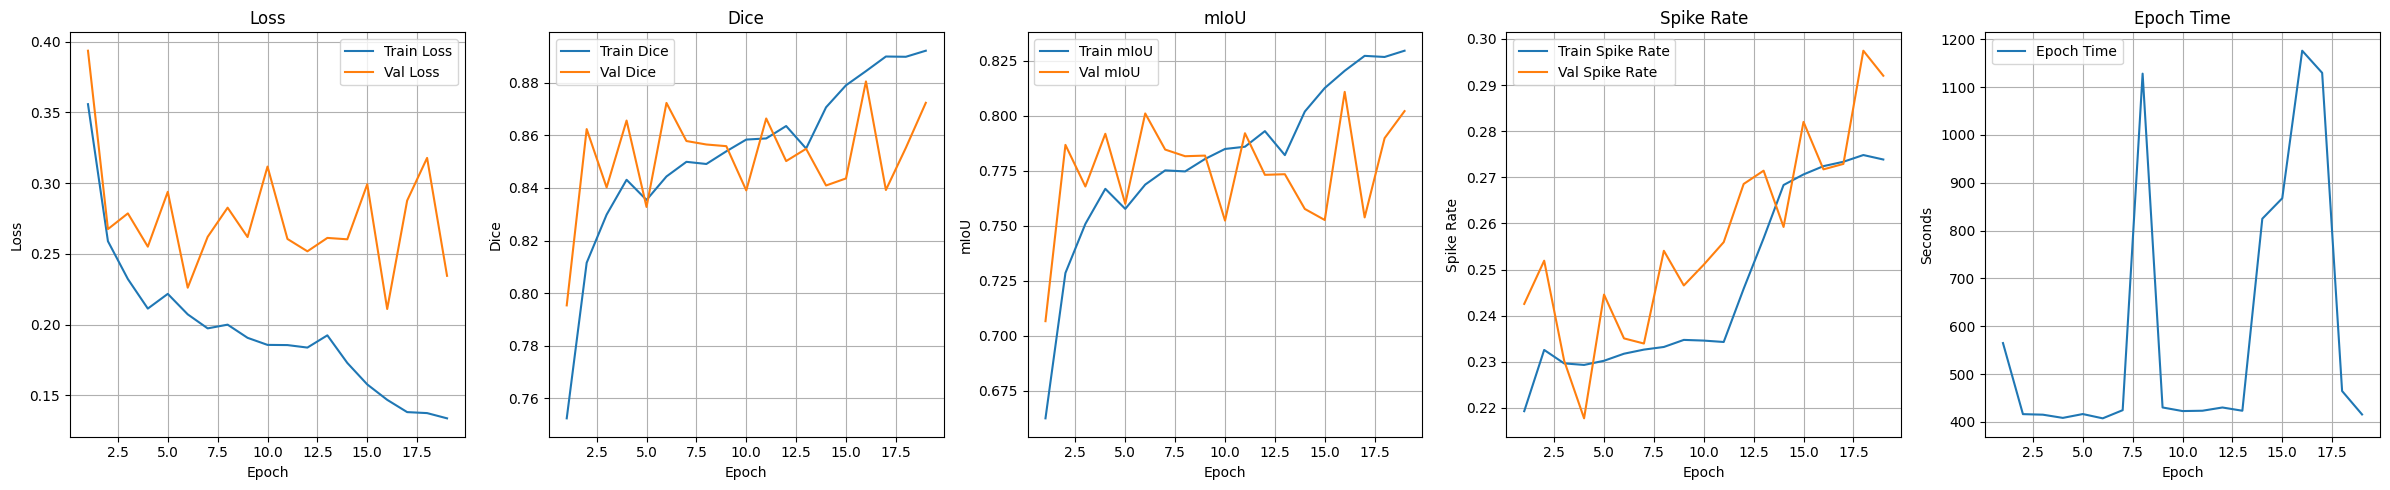

In [ ]:


def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(24, 5))

    # Loss
    plt.subplot(1, 5, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.grid()

    # Dice
    plt.subplot(1, 5, 2)
    plt.plot(epochs, history["train_dice"], label="Train Dice")
    plt.plot(epochs, history["val_dice"], label="Val Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.title("Dice")
    plt.legend()
    plt.grid()

    # mIoU
    plt.subplot(1, 5, 3)
    plt.plot(epochs, history["train_miou"], label="Train mIoU")
    plt.plot(epochs, history["val_miou"], label="Val mIoU")
    plt.xlabel("Epoch")
    plt.ylabel("mIoU")
    plt.title("mIoU")
    plt.legend()
    plt.grid()

    # Spike rate
    plt.subplot(1, 5, 4)
    plt.plot(epochs, history["train_spike_rate"], label="Train Spike Rate")
    plt.plot(epochs, history["val_spike_rate"], label="Val Spike Rate")
    plt.xlabel("Epoch")
    plt.ylabel("Spike Rate")
    plt.title("Spike Rate")
    plt.legend()
    plt.grid()

    # Epoch time
    plt.subplot(1, 5, 5)
    plt.plot(epochs, history["epoch_time"], label="Epoch Time")
    plt.xlabel("Epoch")
    plt.ylabel("Seconds")
    plt.title("Epoch Time")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()


plot_history(history)

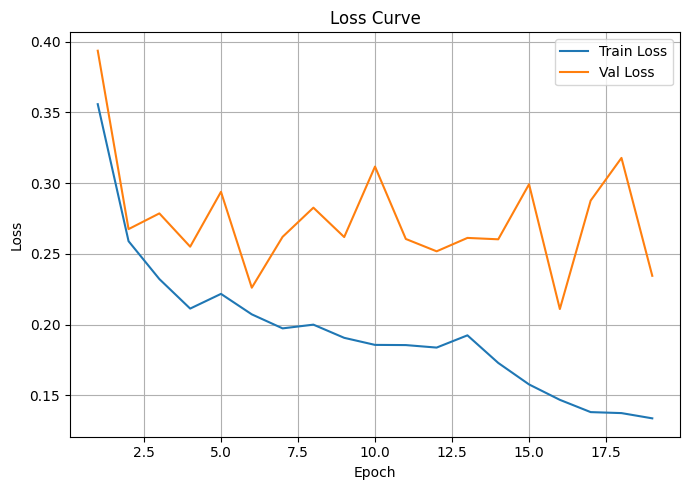

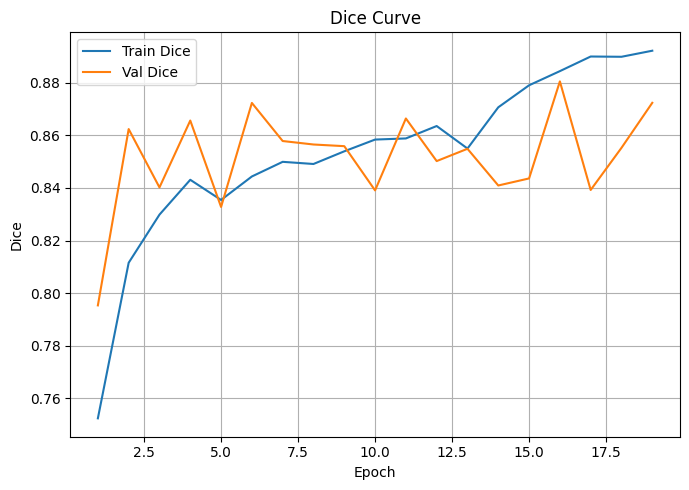

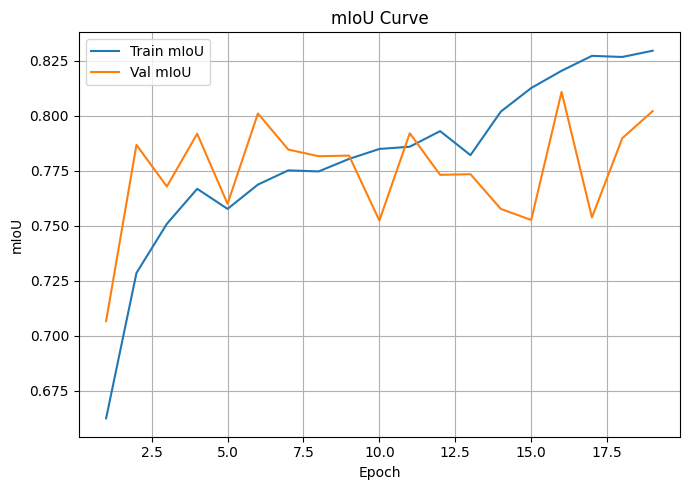

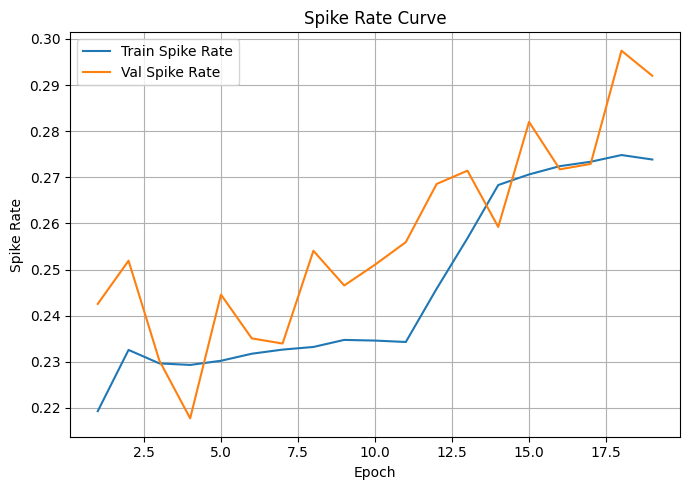

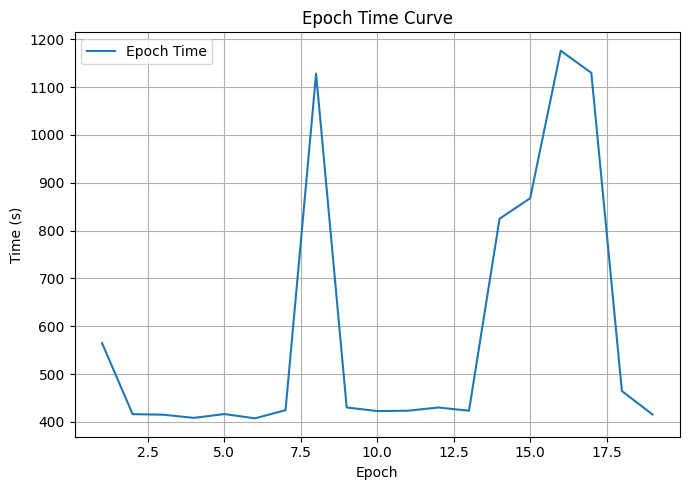

In [28]:
# ============================================================
# CELL 29: Save 600 DPI figures
# ============================================================

def save_history_figures(history, fig_dir=FIG_DIR):
    fig_dir = Path(fig_dir)
    fig_dir.mkdir(parents=True, exist_ok=True)

    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss
    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(fig_dir / f"{RUN_NAME}_loss_curve_600dpi.png", dpi=600)
    plt.show()

    # Dice
    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["train_dice"], label="Train Dice")
    plt.plot(epochs, history["val_dice"], label="Val Dice")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.title("Dice Curve")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(fig_dir / f"{RUN_NAME}_dice_curve_600dpi.png", dpi=600)
    plt.show()

    # mIoU
    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["train_miou"], label="Train mIoU")
    plt.plot(epochs, history["val_miou"], label="Val mIoU")
    plt.xlabel("Epoch")
    plt.ylabel("mIoU")
    plt.title("mIoU Curve")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(fig_dir / f"{RUN_NAME}_miou_curve_600dpi.png", dpi=600)
    plt.show()

    # Spike rate
    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["train_spike_rate"], label="Train Spike Rate")
    plt.plot(epochs, history["val_spike_rate"], label="Val Spike Rate")
    plt.xlabel("Epoch")
    plt.ylabel("Spike Rate")
    plt.title("Spike Rate Curve")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(fig_dir / f"{RUN_NAME}_spike_rate_curve_600dpi.png", dpi=600)
    plt.show()

    # Epoch time
    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["epoch_time"], label="Epoch Time")
    plt.xlabel("Epoch")
    plt.ylabel("Time (s)")
    plt.title("Epoch Time Curve")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.savefig(fig_dir / f"{RUN_NAME}_epoch_time_curve_600dpi.png", dpi=600)
    plt.show()


save_history_figures(history)

In [ ]:


def mask_to_color(mask):
    mask = mask.cpu().numpy()

    H, W = mask.shape
    color = np.zeros((H, W, 3), dtype=np.uint8)

    # Class 1 = lesion, red
    color[mask == 1] = [255, 0, 0]

    return color


def pred_to_color(pred):
    pred = pred.cpu().numpy()

    H, W = pred.shape
    color = np.zeros((H, W, 3), dtype=np.uint8)

    # Class 1 = lesion, green
    color[pred == 1] = [0, 255, 0]

    return color

In [ ]:

def overlay_mask_on_image(image, mask_color, alpha=0.5):
    img = image.permute(1, 2, 0).cpu().numpy()
    img = np.clip(img * 255, 0, 255).astype(np.uint8)

    overlay = cv2.addWeighted(img, 1.0, mask_color, alpha, 0)

    return overlay

In [ ]:


def visualize_sample(image, gt_mask, pred_mask):
    gt_color = mask_to_color(gt_mask)
    pred_color = pred_to_color(pred_mask)

    overlay_gt = overlay_mask_on_image(image, gt_color, alpha=0.5)
    overlay_pred = overlay_mask_on_image(image, pred_color, alpha=0.5)

    img = image.permute(1, 2, 0).cpu().numpy()
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 5, 1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(gt_color)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(pred_color)
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(overlay_gt)
    plt.title("GT Overlay")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(overlay_pred)
    plt.title("Prediction Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Sample ID: ISIC_0036085.jpg
Spike rate: 0.263592


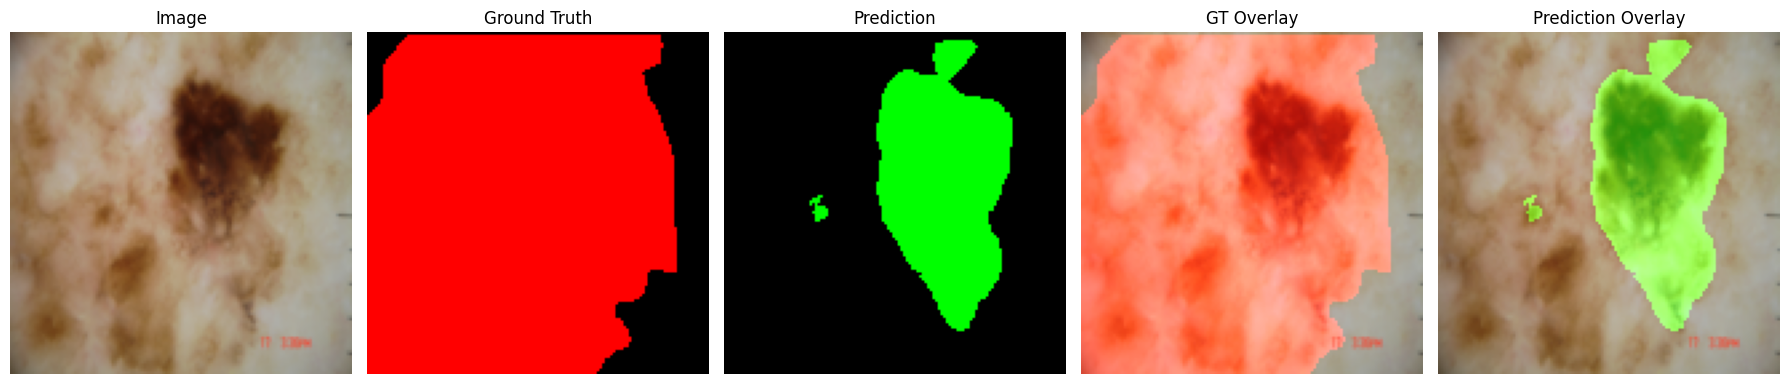

Sample ID: ISIC_0021202.jpg
Spike rate: 0.303157


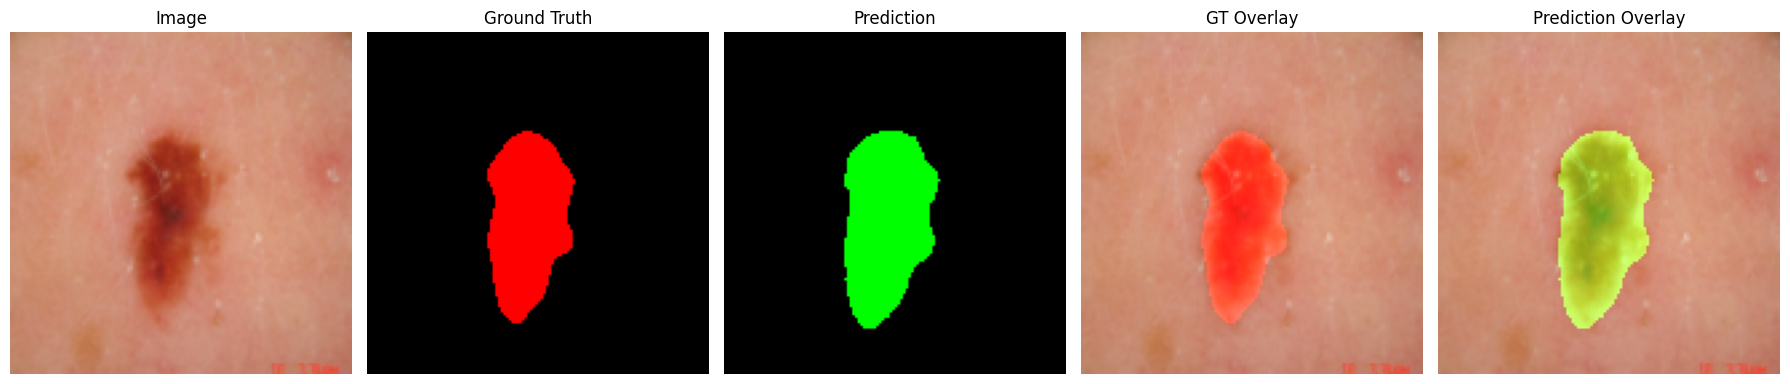

Sample ID: ISIC_0022738.jpg
Spike rate: 0.292193


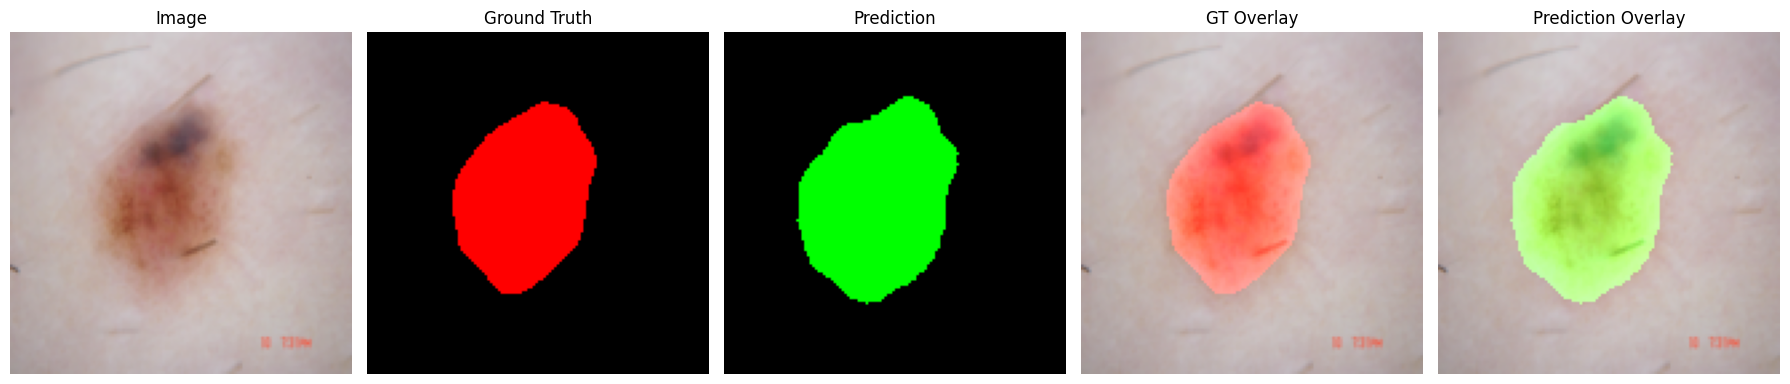

Sample ID: ISIC_0020861.jpg
Spike rate: 0.288758


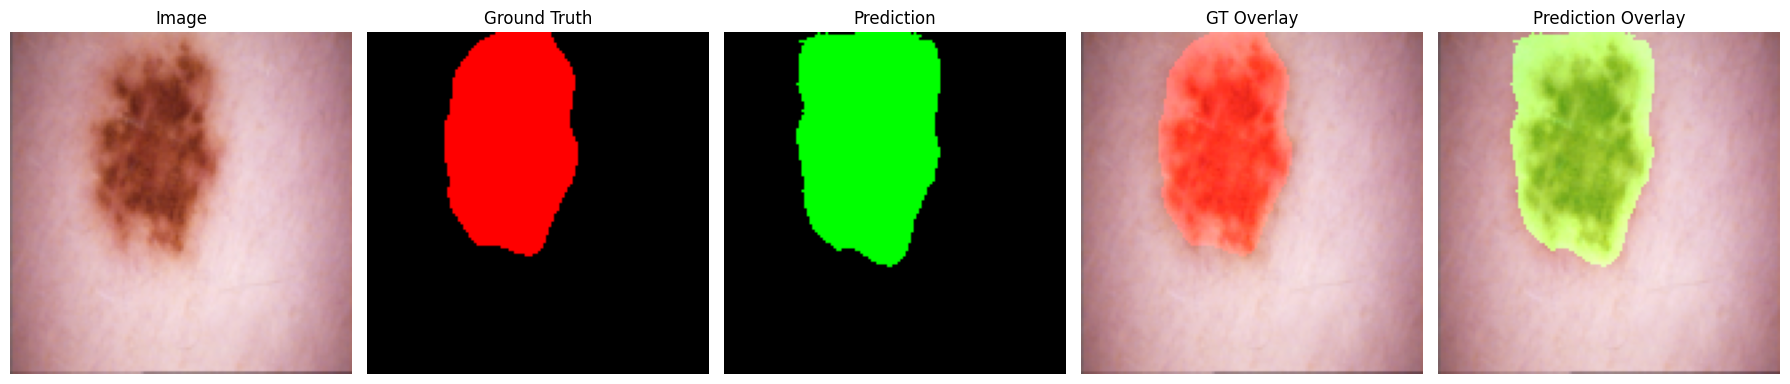

Sample ID: ISIC_0020418.jpg
Spike rate: 0.306423


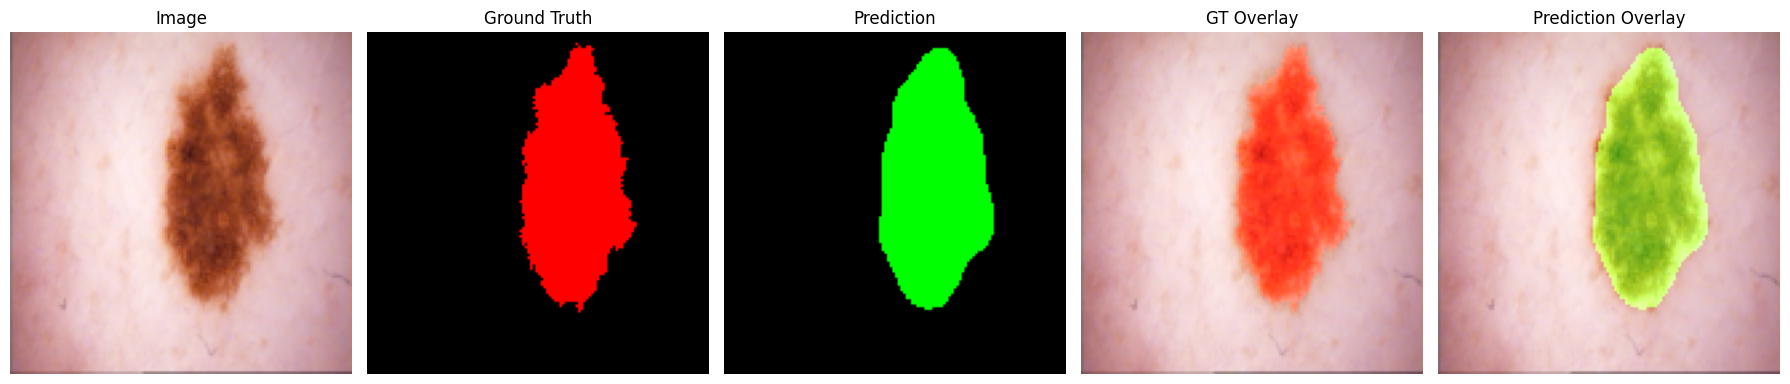

In [ ]:


def visualize_dataset_samples(model, dataset, device, n=5):
    model.eval()

    idxs = np.random.choice(len(dataset), n, replace=False)

    for idx in idxs:
        sample = dataset[idx]

        image = sample["image"].unsqueeze(0).to(device)
        gt_mask = sample["mask"]

        with torch.no_grad():
            logits = model(image)
            pred = torch.argmax(logits, dim=1).squeeze(0)

        print(f"Sample ID: {sample['id']}")
        print(f"Spike rate: {model.last_spike_rate:.6f}")

        visualize_sample(
            image.squeeze(0).cpu(),
            gt_mask.cpu(),
            pred.cpu(),
        )


visualize_dataset_samples(model, Val_dataset, DEVICE, n=5)

In [ ]:


best_model = SpikingULite(
    num_classes=NUM_CLASSES,
    num_steps=NUM_STEPS,
    beta=BETA,
    threshold=THRESHOLD,
    reset_mechanism=RESET_MECHANISM,
).to(DEVICE)

if BEST_CHECKPOINT_PATH.exists():
    ckpt = torch.load(str(BEST_CHECKPOINT_PATH), map_location=DEVICE)

    best_model.load_state_dict(ckpt["model_state"])
    best_model.eval()

    print("Loaded best checkpoint.")
    print("Run name:", ckpt.get("run_name", "unknown"))
    print("Epoch:", ckpt["epoch"])
    print("Best epoch:", ckpt.get("best_epoch", 0))
    print("Best val Dice:", ckpt.get("best_val_dice", 0.0))
    print("Best val mIoU:", ckpt.get("best_val_miou", 0.0))
else:
    print("Best checkpoint not found.")

In [ ]:


visualize_dataset_samples(best_model, Val_dataset, DEVICE, n=5)

In [ ]:


def predict_single_image(model, image_path, device):
    model.eval()

    transform = TVT.Compose([
        TVT.Resize(IMAGE_SIZE),
        TVT.ToTensor(),
    ])

    img_pil = Image.open(image_path).convert("RGB")
    img = transform(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(img)
        pred = torch.argmax(logits, dim=1).squeeze(0)

    return img.squeeze(0).cpu(), pred.cpu(), model.last_spike_rate

# use this for testingg
# Example: exp01a
# image_path = "data/ISIC2018/ISIC2018_Task1-2_Test_Input/ISIC_xxxxxxx.jpg"
# image, pred_mask, spike_rate = predict_single_image(best_model, image_path, DEVICE)
# print("Spike rate:", spike_rate)
#
# pred_color = pred_to_color(pred_mask)
#
# plt.figure(figsize=(10, 5))
#
# plt.subplot(1, 2, 1)
# plt.imshow(image.permute(1, 2, 0))
# plt.title("Input Image")
# plt.axis("off")
#
# plt.subplot(1, 2, 2)
# plt.imshow(pred_color)
# plt.title("Predicted Mask")
# plt.axis("off")
#
# plt.tight_layout()
# plt.show()